# Putative Genetic Load
Given that the tara iti reference genome could not be annotated with RNA sequencing, ensure a robust and conservative assessment of genetic load that is translatable across species comparisons, we limited load estimates to highly conserved BUSCO genes in the fairy tern species complex (*Sterna nereis* spp.) and kakī (*Himantopus novazealandiae*) for comparison.  

To start, we ran BUSCO v5.4.7 for the tara iti and kakī reference genome.  

In [ ]:
busco --in Katie_racon_ragtag_autosomes.fa --out busco/ --mode genome --lineage_dataset aves_odb10 --cpu 32
busco --in himNova-hic-scaff_autosomes.fa --out busco/ --mode genome --lineage_dataset aves_odb10 --cpu 32

We then concatenated single copy BUSCO sequences into species specific `GFF` files.  

In [ ]:
cat busco/run_aves_odb10/busco_sequences/single_copy_busco_sequences/*.gff > SIFT_DB/TI_annotation/merged_scBUSCOs.gff
cat busco/run_aves_odb10/busco_sequences/single_copy_busco_sequences/*.gff > SIFT_DB/KI_annotation/merged_scBUSCOs.gff

cat busco/run_aves_odb10/busco_sequences/single_copy_busco_sequences/*.faa > SIFT_DB/TI_annotation/merged_scBUSCOs.fa
cat busco/run_aves_odb10/busco_sequences/single_copy_busco_sequences/*.faa > SIFT_DB/KI_annotation/merged_scBUSCOs.fa

We opted to convert the `GFF` files output from BUSCO to `GTF` with [agat](https://github.com/NBISweden/AGAT) v. 1.0.0. First we fixed the concatenated `GFF` from BUSCO to be more compatible with Ensemble's Variant Effect Predictor (VEP).  

In [ ]:
agat_sp_manage_IDs.pl --gff KI_annotations/merged_scBUSCO.gff -o KI_annotations/merged_scBUSCO_checked.gff
agat_sp_manage_IDs.pl --gff TI_annotations/merged_scBUSCO.gff -o TI_annotations/merged_scBUSCO_checked.gff

This `GFF` was then converted to `GTF` with AGAT and errors in coordinates (where the end position is before the start position) were corrected before sorting, file compression with `bgzip` and indexing with `tabix`.  130 records in the TI genome and 55 records in the kaki genome had ending positions that occurred before the start positions. These start/end positions were flipped in order to not crash VEP.  

In [ ]:
agat_convert_sp_gff2gtf.pl --gff KI_annotations/merged_scBUSCO_checked.gff -o KI_annotations/merged_scBUSCO_checked.gtf
agat_convert_sp_gff2gtf.pl --gff TI_annotations/merged_scBUSCO_checked.gff -o TI_annotations/merged_scBUSCO_checked.gtf

cat KI_annotations/merged_scBUSCO_checked.gtf | \
    awk '{ if ($5<$4) print $1"\t"$2"\t"$3"\t"$5"\t"$4"\t"$6"\t"$7"\t"$8"\t"$9"\t"$10"\t"$11"\t"$12"\t"$13"\t"$14,$15,$16,$17,$18,$19,$20,$21,$22; else print $0}' | \
    sort -k1,1 -k4,4n -k5,5n -t$'\t' | bgzip -c > KI_annotations/scBUSCO_coordinates_fixed.gtf.gz
cat TI_annotations/merged_scBUSCO_checked.gtf | \
    awk '{ if ($5<$4) print $1"\t"$2"\t"$3"\t"$5"\t"$4"\t"$6"\t"$7"\t"$8"\t"$9"\t"$10"\t"$11"\t"$12"\t"$13"\t"$14,$15,$16,$17,$18,$19,$20,$21,$22; else print $0}' | \
    sort -k1,1 -k4,4n -k5,5n -t$'\t' | bgzip -c > TI_annotations/scBUSCO_coordinates_fixed.gtf.gz

tabix -p gff KI_annotations/scBUSCO_coorinates_fixed.gtf.gz
tabix -p gff TI_annotations/scBUSCO_coorinates_fixed.gtf.gz

### Sites Polarised with ANGSD
To estimate masked and realised load in each fairy tern population and kakī we used ANGSD to output the major minor alleles, the called genotype, the posterior probability of the called genotype and all possible genotypes (`-doGeno 31`) to a BCF file (`-doBcf 1`).  

In [ ]:
angsd -P 24 -b ${ANGSD}GLOBAL.list -ref ${TREF} -anc ${TANC} -out ${ANGSD}samtools/genotypes/GLOBAL_polarized \
        -uniqueOnly 1 -remove_bads 1 -only_proper_pairs 1 -trim 0 -C 50 -baq 1 -skipTriallelic 1 \
        -minMapQ 20 -minQ 20 -minInd 57 -setMinDepth 555 -setMaxDepth 1056 -doCounts 1 \
        -doPost 1 -postCutoff 0.95 -doBcf 1 -GL 1 -doMajorMinor 5 -doMaf 1 -SNP_pval 1e-6 -doGeno 31 --ignore-RG 0

angsd -P 32 -b ${DIR}KI.list -ref ${KREF} -anc ${KANC} -out ${DIR}samtools/genotypes/KI_polarized \
        -uniqueOnly 1 -remove_bads 1 -only_proper_pairs 1 -trim 0 -C 50 -baq 1 -skipTriallelic 1 \
        -minMapQ 20 -minQ 20 -minInd 24 -setMinDepth 700 -maxDepth 1200 -doCounts 1 \
        -doPost 1 -postCutoff 0.95 -doBcf 1 -GL 1 -doMajorMinor 5 -doMaf 1 -SNP_pval 1e-6 -doGeno 31 --ignore-RG 0


### Variant Effect Predictor
VEP was run below using the GTF files constructed above.  

In [ ]:
vep -i GLOBAL_variable_alt.vcf \
    --gtf TI_annotations/scBUSCO_checked_coordinate_corrected.gtf.gz \
    --fasta Katie_autosomes.fa \
    -o vep_data/angsd_high_confidence_BUSCO_SNPs/GLOBAL_whole-genome_polarized

vep -i KI_variable_alt.vcf \
    --gtf KI_annotation/scBUSCO_checked_coordinate_corrected.gtf.gz \
    --fasta references/kaki_autosomes.fa \
    -o vep_data/angsd_high_confidence_BUSCO_SNPs/KI_whole-genome_polarized

A brief check showed that all sites marked deleterious in SIFT had some impact in VEP.  
These intersecting sites were then extracted from the filtered SNPs, and allele frequency estimated for each fairy tern population.

In [ ]:
while read -r line
    do
    POSIT=$(echo $line | awk '{print $1}')
    AALLE=$(bcftools query --threads 4 -t ${POSIT} -f '[%GT\n]' GLOBAL_variable_alt_AU.bcf | sed 's%0/0%0%g' | sed 's%0/1%1%g'| sed 's%1/1%2%g' | awk '{sum += $1}; END {print sum}')
    TALLE=$(bcftools query --threads 4 -t ${POSIT} -f '[%GT\n]' GLOBAL_variable_alt_TI.bcf | sed 's%0/0%0%g' | sed 's%0/1%1%g'| sed 's%1/1%2%g' | awk '{sum += $1}; END {print sum}')
    printf "$line\t$AALLE\tAU\n" >> pop_harmful_allele_frequency2.tsv
    printf "$line\t$TALLE\tNZ\n" >> pop_harmful_allele_frequency2.tsv
    echo $line
done < fairy_harmful_allele.txt

There were roughly 134 and XXX sites in the fairy tern and kakī data sets that had ambiguous mutation types and consequences, that is to say the same site had multiple mutation types and consequences. These sites were excluded from all downstream analyses to ensure a conservative estimate of putative mutation load.  

In [ ]:
sort fairy_harmful_allele.txt | uniq | \
    cut -f1 | \
    sort | \
    uniq -c | \
    awk '{if ($1>1) print $2}' > fairy_exclude.tsv

Then we counted the number of alleles per site, per individual for all derived alleles and their consequences as inferred by VEP.  

In [ ]:
while read -r line
    do
    POSIT=$(echo $line | awk '{print $1}')
    EFFECT=$(echo $line | awk '{print $3}')
    echo "$line"
    if [["$EFFECT" == "LOW"]]; then
        bcftools query -t ${POSIT} -f '[%CHROM\t%POS\t$SAMPLE\t%GT\tAU\tLow]' GLOBAL_variable_alt_AU.vcf >> indiv_harmful_allele_frequency.tsv
        bcftools query -t ${POSIT} -f '[%CHROM\t%POS\t$SAMPLE\t%GT\tTI\tLow]' GLOBAL_variable_alt_TI.vcf >> indiv_harmful_allele_frequency.tsv
    elif [["$EFFECT" == "MODERATE"]]; then
        bcftools query -t ${POSIT} -f '[%CHROM\t%POS\t$SAMPLE\t%GT\tAU\tModerate]' GLOBAL_variable_alt_AU.vcf >> indiv_harmful_allele_frequency.tsv
        bcftools query -t ${POSIT} -f '[%CHROM\t%POS\t$SAMPLE\t%GT\tTI\tModerate]' GLOBAL_variable_alt_TI.vcf >> indiv_harmful_allele_frequency.tsv
    elif [["$EFFECT" == "HIGH"]]; then
        bcftools query -t ${POSIT} -f '[%CHROM\t%POS\t$SAMPLE\t%GT\tAU\tHigh]' GLOBAL_variable_alt_AU.vcf >> indiv_harmful_allele_frequency.tsv
        bcftools query -t ${POSIT} -f '[%CHROM\t%POS\t$SAMPLE\t%GT\tTI\tHigh]' GLOBAL_variable_alt_TI.vcf >> indiv_harmful_allele_frequency.tsv
    else
        bcftools query -t ${POSIT} -f '[%CHROM\t%POS\t$SAMPLE\t%GT\tAU\tModifier]' GLOBAL_variable_alt_AU.vcf >> indiv_harmful_allele_frequency.tsv
        bcftools query -t ${POSIT} -f '[%CHROM\t%POS\t$SAMPLE\t%GT\tTI\tModifier]' GLOBAL_variable_alt_TI.vcf >> indiv_harmful_allele_frequency.tsv
    fi
done < fairy_alleles.txt

## Load Estimates
### Harmful allele frequency
The sum of sc-BUSCO gene regions is 289,743,567bp in kakī and 227,780,539bp in tara iti. This corresponds to roughly 26% and 21% of the kakī and fairy tern genomes. 

First we examined the frequency of the derived alleles determined to be 'Deleterious' by SIFT. Here, we can see that the presence of derived harmful alleles is markedly lower in tara iti than the other two populations.  

For each inidividual, we counted the number of intolerant (SIFT score <=0.05), tolerated (SIFT score >0.05 & <=0.10), and the sum of all nonsynonmyous SNPs as called within BUSCO regions.  

Here plotting Allele count for derived alleles per individuals for those nonsynonymous mutations classed as intolerant (fairy terns n = 1,800, KI n = 1,172) and tolerant (fairy terns n = 4,396, KI n = 5,426) falling within BUSCO regions.

In [2]:
import os
import re
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.legend_handler import HandlerTuple

path = '/nesi/nobackup/uc03718/'
os.chdir(path)
print(os.getcwd())

/nesi/nobackup/uc03718


In [4]:
# Group by 'Population', 'Mutation Class', and 'Consequence' and sum 'Allele Count'
del_allele = pd.read_csv('VEP/pop_harmful_allele_frequency.tsv', delimiter='\t', names=['Chromosome', 'Mutation Class', 'Consequence', 'Allele Count', 'Population'])
del_allele_count = del_allele.groupby(['Population', 'Consequence'])['Allele Count'].sum().reset_index()

print(del_allele_count)

  Population Consequence  Allele Count
0         AU        HIGH          1942
1         AU         LOW         75916
2         AU    MODERATE         25354
3         NZ        HIGH          2457
4         NZ         LOW        169049
5         NZ    MODERATE          4733


We then examined allele frequency of putatively harmful alleles in AFT, tara iti, low and high coverage kakī data sets.  

In [8]:
#pop_harm = del_allele[del_allele['Consequence']=='Intolerant']
pop_harm = del_allele
pop_harm = pop_harm[pop_harm['Allele Count']>0]

au_harm_counts = pop_harm[pop_harm['Population']=='AU'].groupby(["Allele Count", "Population"]).size().reset_index(name="Frequency")
ti_harm_counts = pop_harm[pop_harm['Population']=='NZ'].groupby(["Allele Count", "Population"]).size().reset_index(name="Frequency")
#ki_harm_counts = pop_harm[pop_harm['Population']=='KI'].groupby(["Allele Count", "Population"]).size().reset_index(name="Frequency")

au_harm_pivot = au_harm_counts.pivot(index="Allele Count", columns="Population", values="Frequency").fillna(0)
ti_harm_pivot = ti_harm_counts.pivot(index="Allele Count", columns="Population", values="Frequency").fillna(0)
#ki_harm_pivot = ki_harm_counts.pivot(index="Allele Count", columns="Population", values="Frequency").fillna(0)

pop_harm.head()

,Chromosome,Mutation Class,Consequence,Allele Count,Population
1,CM020437.1_RagTag:100153666,synonymous_variant,LOW,5,AU
3,CM020437.1_RagTag:100261341,synonymous_variant,LOW,1,AU
5,CM020437.1_RagTag:100261455,synonymous_variant,LOW,38,AU
7,CM020437.1_RagTag:100262462,missense_variant,MODERATE,3,AU
9,CM020437.1_RagTag:100789127,missense_variant,MODERATE,14,NZ


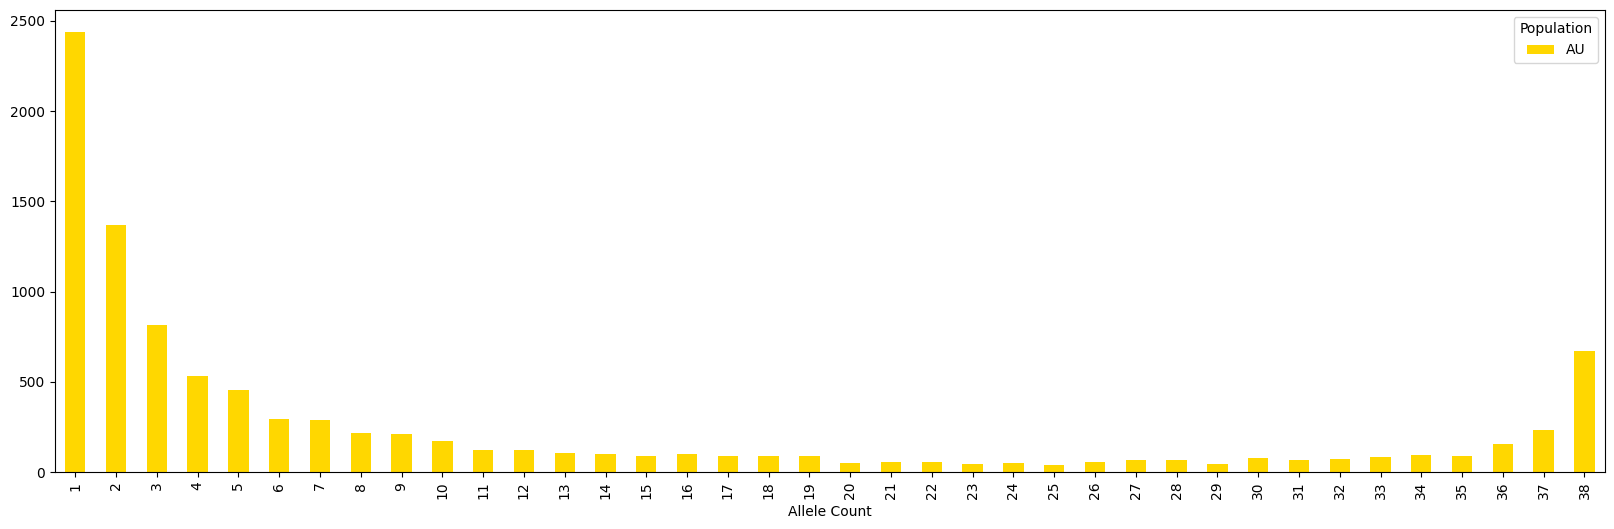

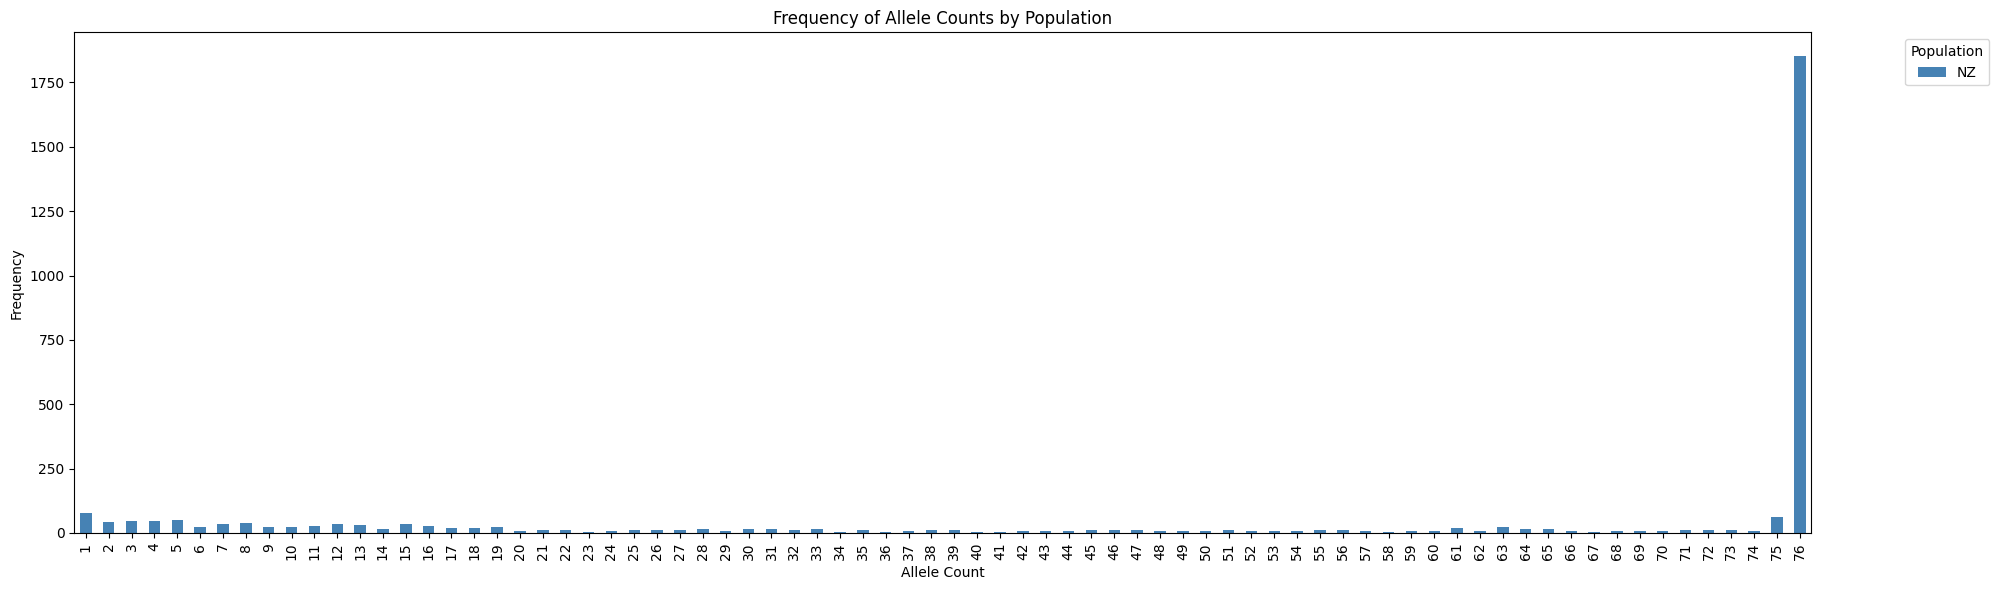

In [10]:
# Plot a stacked bar chart
au_harm_pivot.plot(kind="bar", stacked=True, figsize=(20, 6), color="gold")
ti_harm_pivot.plot(kind="bar", stacked=True, figsize=(20, 6), color="steelblue")
#ki_harm_pivot.plot(kind="bar", stacked=True, figsize=(12, 6), color="black")

plt.title("Frequency of Allele Counts by Population")
plt.ylabel("Frequency")
plt.xlabel("Allele Count")
plt.legend(title="Population", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [11]:
au_harm = del_allele[(del_allele['Consequence']!='MODIFIER') & (del_allele['Population']=='AU')]
au_harm['Allele Frequency'] = au_harm['Allele Count'] / (19 * 2)
ti_harm = del_allele[(del_allele['Consequence']!='MODIFIER') & (del_allele['Population']=='NZ')]
ti_harm['Allele Frequency'] = ti_harm['Allele Count'] / (38 * 2)
ki_harm = del_allele[(del_allele['Consequence']!='MODIFIER') & (del_allele['Population']=='KI')]
ki_harm['Allele Frequency'] = ki_harm['Allele Count'] / (24 *2)

print('The mean allele frequency of putatively harmful alleles in AFT: ', au_harm['Allele Frequency'].mean())
print('The mean allele frequency of putatively harmful alleles in TI:  ', ti_harm['Allele Frequency'].mean())
print('The mean allele frequency of putatively harmful alleles in KI:  ', ki_harm['Allele Frequency'].mean())

The mean allele frequency of putatively harmful alleles in AFT:  0.23657392763329807
The mean allele frequency of putatively harmful alleles in TI:   0.20198015943962336
The mean allele frequency of putatively harmful alleles in KI:   nan


/tmp/ipykernel_180078/616032219.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  au_harm['Allele Frequency'] = au_harm['Allele Count'] / (19 * 2)
/tmp/ipykernel_180078/616032219.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ti_harm['Allele Frequency'] = ti_harm['Allele Count'] / (38 * 2)


<Axes: xlabel='Population', ylabel='Allele Frequency'>

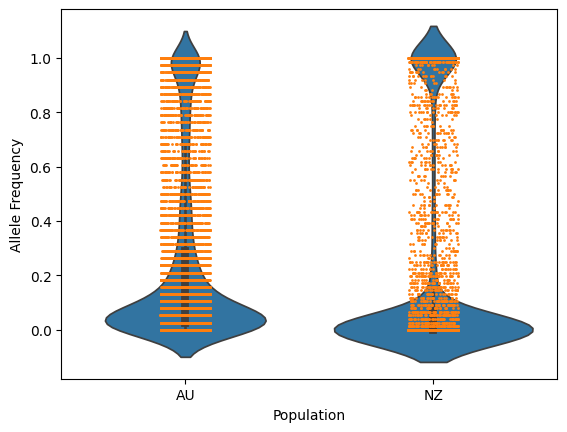

In [12]:
total_harm = pd.concat([au_harm, ti_harm, ki_harm], axis=0, ignore_index=True)
sns.violinplot(data=total_harm, x='Population', y='Allele Frequency')
sns.stripplot(data=total_harm, x='Population', y='Allele Frequency', jitter=True, size=2)

We then estimated R<sub>xy</sub> between each of the three populations for putatively intolerant, tolerant, and all synonymous mutations. The [code](https://github.com/samarth8392/MQU_EvoGenomics/blob/main/RScripts/Rxy.R) below was adapted from [Mathur et al (2023)](http://doi.org/10.1093/evolut/qpac061).  

In [ ]:
def estimate_rxy(df, pop1, pop2, consequence, chroms_df):
    # Separate deleterious and synonymous data based on consequence type
    del_df = df[(df['Consequence'] == consequence)]
    syn_df = df[df['Mutation Class'] == 'SYNONYMOUS']

    # Merge data for both populations
    del_merged = pd.merge(del_df[del_df['Population'] == pop1], del_df[del_df['Population'] == pop2],
                          on=['Chromosome', 'Position'], suffixes=('_pop1', '_pop2'))
    
    syn_merged = pd.merge(syn_df[syn_df['Population'] == pop1], syn_df[syn_df['Population'] == pop2],
                          on=['Chromosome', 'Position'], suffixes=('_pop1', '_pop2'))

    # Calculate l_xy and l_yx
    l_xy = np.sum(del_merged["Allele Frequency_pop1"] * (1 - del_merged["Allele Frequency_pop2"])) / np.sum(syn_merged["Allele Frequency_pop1"] * (1 - syn_merged["Allele Frequency_pop2"]))
    l_yx = np.sum(del_merged["Allele Frequency_pop2"] * (1 - del_merged["Allele Frequency_pop1"])) / np.sum(syn_merged["Allele Frequency_pop2"] * (1 - syn_merged["Allele Frequency_pop1"]))
    
    # Initialize results list
    Rxy_results = []

    # Loop over chromosomes
    for chr in chroms_df['Chromosome']:
        # Filter data excluding one chromosome at a time
        del_df_excluded = del_df[(del_df['Chromosome'] != chr)]
        syn_df_excluded = syn_df[(syn_df['Chromosome'] != chr)]

        # Merge excluded data for both populations
        del_excluded_merged = pd.merge(del_df_excluded[del_df_excluded['Population'] == pop1],
                                      del_df_excluded[del_df_excluded['Population'] == pop2],
                                      on=['Chromosome', 'Position'], suffixes=('_pop1', '_pop2'))
        
        syn_excluded_merged = pd.merge(syn_df_excluded[syn_df_excluded['Population'] == pop1],
                                      syn_df_excluded[syn_df_excluded['Population'] == pop2],
                                      on=['Chromosome', 'Position'], suffixes=('_pop1', '_pop2'))

        # Calculate l_xy_excluded and l_yx_excluded
        l_xy_excluded = np.sum(del_excluded_merged["Allele Frequency_pop1"] * (1 - del_excluded_merged["Allele Frequency_pop2"])) / np.sum(syn_excluded_merged["Allele Frequency_pop1"] * (1 - syn_excluded_merged["Allele Frequency_pop2"]))
        l_yx_excluded = np.sum(del_excluded_merged["Allele Frequency_pop2"] * (1 - del_excluded_merged["Allele Frequency_pop1"])) / np.sum(syn_excluded_merged["Allele Frequency_pop2"] * (1 - syn_excluded_merged["Allele Frequency_pop1"]))

        # Calculate rxy_excluded
        rxy_excluded = l_xy_excluded / l_yx_excluded

        # Append result to list
        Rxy_results.append({'Chromosome Excluded': chr, 'Rxy': rxy_excluded, 'Consequence': consequence})

    # Convert list of dictionaries to DataFrame
    Rxy_results_df = pd.DataFrame(Rxy_results)

    return Rxy_results_df

In [ ]:
def calculate_allele_frequency(row):
    if row['Population'] == 'NZ':
        return row['Allele Count'] / (38 * 2)
    elif row['Population'] == 'AU':
        return row['Allele Count'] / (19 * 2)
    else:
        return None  # Handle other cases if needed

# Load and process data so we have Allele frequency column
del_pop_allele = pd.read_csv('load/pop_allele_frequency.tsv', delimiter='\t')
del_pop_allele = del_pop_allele[del_pop_allele['Population']!='KI']
del_pop_allele['Mutation Class'] = del_pop_allele['Mutation Class'].replace('START-LOST', 'NONSYNONYMOUS')
del_pop_allele = del_pop_allele[del_pop_allele['Allele Count']>0]

intergenic = del_pop_allele[(del_pop_allele['Mutation Class'] == 'intergenic_variant') & ( del_pop_allele['Consequence'] == 'Modifier')]
intergenic = intergenic.drop_duplicates(subset=['Chromosome', 'Position', 'Population'])
intergenic = intergenic.groupby(['Chromosome', 'Position']).filter(lambda x: len(x) == 2)

# Apply the function to create a new column 'Allele Frequency'
del_pop_allele['Allele Frequency'] = del_pop_allele.apply(lambda row: calculate_allele_frequency(row), axis=1)
intergenic['Allele Frequency'] = intergenic.apply(lambda row: calculate_allele_frequency(row), axis=1)

chromNames = del_pop_allele['Chromosome'].sort_values().drop_duplicates()
chromNames = pd.DataFrame(chromNames, columns=['Chromosome'])

In [ ]:
intergenic.head()

In [ ]:
del_Rxy = estimate_rxy(del_pop_allele, 'NZ', 'AU', 'Intolerant', chromNames)
tol_Rxy = estimate_rxy(del_pop_allele, 'NZ', 'AU', 'Tolerant', chromNames)
neutral_Rxy = estimate_rxy(intergenic, 'NZ', 'AU', 'Intergenic', chromNames)
Rxy = pd.concat([del_Rxy, tol_Rxy, neutral_Rxy], ignore_index=True)
Rxy_noNeutral = pd.concat([del_Rxy, tol_Rxy], ignore_index=True)

print("Mean Rxy: ", tol_Rxy['Rxy'].mean(), del_Rxy['Rxy'].mean(), neutral_Rxy['Rxy'].mean())

## Putatively harmful Allele diversity

In [ ]:
indiv_del = pd.read_csv('load/indiv_harmful_allele_frequency.tsv', delimiter='\t')

In [ ]:
replace_map = {
    '0/0': 0,
    '0/1': 1,
    '1/1': 2
}

indiv_del['Genotype'] = indiv_del['Genotype'].replace(replace_map)
indiv_del['Pop_Consequence'] = indiv_del['Population'] + '-' + indiv_del['Consequence']

indiv_del.head()